<a href="https://colab.research.google.com/github/Alakhg1408/PES2UG24CS051_VDUI_2/blob/branch-4/unit2_ppt7_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

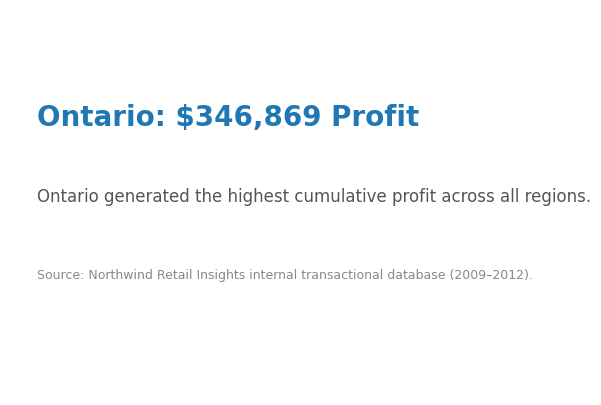

In [2]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# TODO 1: primary element -- large, bold, colored
ax.text(
    0.05,
    0.70,
    f"{best_region}: ${region_totals.max():,.0f} Profit",
    fontsize=20,
    fontweight="bold",
    color="#1f77b4",
)

# TODO 2: secondary element -- medium, muted color
ax.text(
    0.05,
    0.50,
    f"{best_region} generated the highest cumulative profit across all"
    " regions.",
    fontsize=12,
    fontweight="normal",
    color="#555555",
)

# TODO 3: tertiary element -- small, light gray
ax.text(
    0.05,
    0.30,
    "Source: Northwind Retail Insights internal transactional database"
    " (2009–2012).",
    fontsize=9,
    fontweight="normal",
    color="#888888",
)

plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

_Your answer:_ Visual Landing Order: The viewer's eyes land first on the large, saturated blue headline (Ontario: $346,869 Profit), drop second to the medium neutral explanatory sentence, and read the small, low-contrast gray footnote last.   2-Second Takeaway: A viewer walking away after 2 seconds retains the core fact that Ontario is the top-performing profit driver across the company.

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

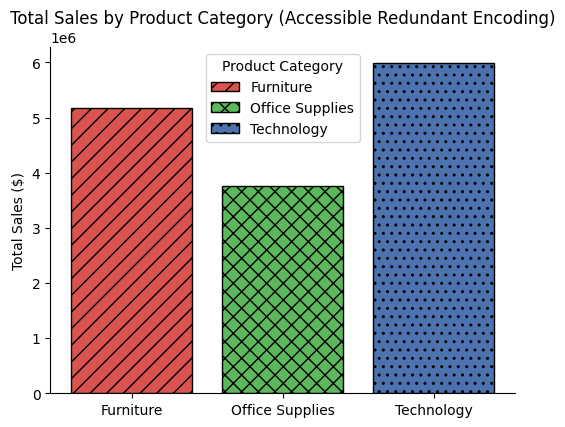

In [3]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

# TODO 1 & 2: bars with both a distinct color AND a distinct hatch pattern per category
colors = {
    "Furniture": "#D9534F",
    "Office Supplies": "#5cb85c",
    "Technology": "#4C72B0",
}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat in cat_sales.index:
  ax.bar(
      cat,
      cat_sales[cat],
      color=colors[cat],
      hatch=hatches[cat],
      edgecolor="black",
      label=cat,
  )

# TODO 3: legend
ax.legend(title="Product Category")
ax.set_ylabel("Total Sales ($)")
ax.set_title("Total Sales by Product Category (Accessible Redundant Encoding)")
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

_Your answer:_ Colorblind Inaccessibility (e.g., Deuteranopia / Protanopia): Red and green categories (Furniture vs. Office Supplies) collapse into visually indistinguishable olive-brown shades when hue is the sole differentiator.   Grayscale Printing Loss: Monochromatic black-and-white office copiers flatten colors of similar lightness/luminance into identical shades of gray, rendering the bars unidentifiable without pattern hatching or direct labeling.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

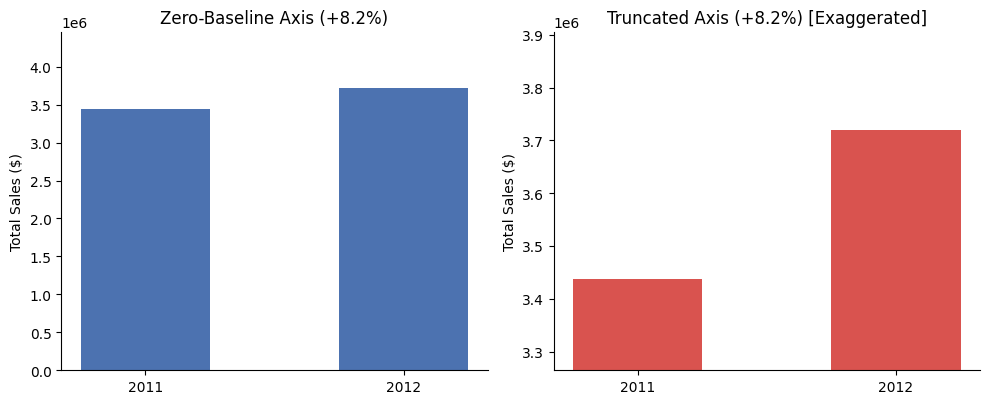

Real change from 2011 to 2012: +8.2%


In [4]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

# TODO 1 & 2: the two most recent years and their real percent change
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales.loc[y1], yearly_sales.loc[y2]
pct_change = ((v2 - v1) / v1) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# TODO 3a: zero-baseline version (axes[0])
axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0", width=0.5)
axes[0].set_ylim(0, max(v1, v2) * 1.2)
axes[0].set_ylabel("Total Sales ($)")
axes[0].set_title(f"Zero-Baseline Axis ({pct_change:+.1f}%)")

# TODO 3b: truncated-axis version (axes[1]) -- pick tight y-limits close to v1/v2
axes[1].bar([str(y1), str(y2)], [v1, v2], color="#D9534F", width=0.5)
axes[1].set_ylim(min(v1, v2) * 0.95, max(v1, v2) * 1.05)
axes[1].set_ylabel("Total Sales ($)")
axes[1].set_title(f"Truncated Axis ({pct_change:+.1f}%) [Exaggerated]")

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")

**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

_Your answer:_ I would flag the truncated-axis panel (axes[1]) as severely misleading. In bar charts, readers naturally judge quantities by the physical height and area of the bar starting from zero. Truncating the y-axis causes a modest +8.2% annual growth to visually look like sales quadrupled, creating an artificial sensation of a dramatic surge (or crisis) not supported by the underlying magnitude.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales increased by 8.2% from 2011 to 2012.
INTERPRETIVE: Sales increased by 8.2% in 2012, consistent with growth across Technology and regional expansion.


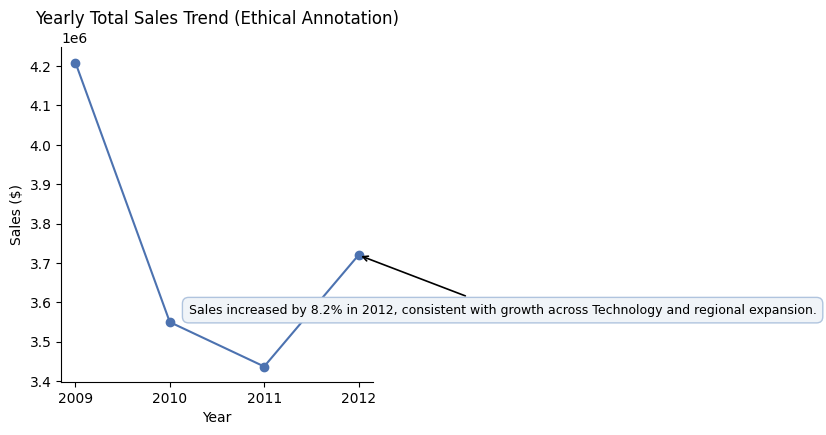

In [5]:
overreaching_original = (
    "This PROVES our new strategy is working -- scale it up immediately"
)

# TODO 1: your rewrites
descriptive_version = f"Sales increased by {pct_change:.1f}% from {y1} to {y2}."
interpretive_version = (
    f"Sales increased by {pct_change:.1f}% in {y2}, consistent with growth"
    " across Technology and regional expansion."
)

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

# TODO 2: plot with your interpretive annotation on the last data point
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")

ax.annotate(
    interpretive_version,
    xy=(y2, v2),
    xytext=(y2 - 1.8, v2 * 0.96),
    arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.2),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f4f8", edgecolor="#b0c4de"),
)

ax.set_title("Yearly Total Sales Trend (Ethical Annotation)")
ax.set_xlabel("Year")
ax.set_ylabel("Sales ($)")
ax.set_xticks(yearly_sales.index)
plt.tight_layout()
plt.show()

**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

_Your answer:_ To substantiate the claim that the new strategy caused this increase, we would need a randomized controlled trial / A/B test with an unexposed control group, econometric counterfactual modeling (e.g., difference-in-differences), and data controlling for macroeconomic tailwinds, seasonal consumer cycles, and promotional marketing discounts. Without a control baseline, observational aggregate correlation cannot prove causation.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_ The most critical fix to ship immediately is enforcing a zero-baseline on the comparative bar chart (Task 3), because truncated baselines distort physical area perception and can lead executives into misallocating capital based on an exaggerated +8.2% sales shift. This addresses the Ethical Visualization Audit question: "Does the visual encoding (bar area) proportionally reflect the true numerical ratio in the data?" Furthermore, replacing overreaching causal words with hedged interpretive annotations prevents the team from asserting unfounded causal claims. As a permanent guardrail, our team should adopt a pre-publish checklist rule requiring zero-anchored bar charts, dual-encoding (color + pattern) for categorical metrics, and mandatory causality peer-review for narrative annotations.